# PatrolIQ - Notebook 5: Dimensionality Reduction (PCA and t-SNE)

**Goal:** Compress our many crime features down into a smaller number of
dimensions, both to understand which features matter most, and to visualize the
data in 2D.

**Why we need this:** We have around 15-18 features describing each crime
(location, time, crime type, arrest status, etc). Humans can't visualize more than
2-3 dimensions at once, so we use PCA and t-SNE to compress this information down
in different ways:
- **PCA** finds the directions of maximum variance (spread) in the data - good for
  understanding which features matter most.
- **t-SNE** focuses on keeping similar points close together in a 2D plot - good for
  visually spotting natural groupings.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import joblib

df = pd.read_csv("../outputs/data_with_all_clusters.csv")
df.shape

(99939, 32)

## Step 1: Build the Feature Set

We select numeric and encoded categorical features that describe each crime record.

**Why we use Label Encoding here (not One-Hot Encoding):** `primary_type` has 31
different categories and `location_description` has many too. One-hot encoding
would create 30+ new columns, which would make our feature set huge and would
actually hurt PCA (since PCA looks at variance, and lots of sparse 0/1 columns
distort that). Label Encoding keeps it to a single column per feature, which is
simpler and works fine for PCA and clustering purposes here.

In [2]:
le_primary_type = LabelEncoder()
le_location_desc = LabelEncoder()

df["primary_type_encoded"] = le_primary_type.fit_transform(df["primary_type"])
df["location_description_encoded"] = le_location_desc.fit_transform(df["location_description"])

**Removing duplicate/redundant features:** Before selecting our final feature
list, we checked for highly correlated columns. We found that `x_coordinate`/
`y_coordinate` are almost perfectly correlated with `latitude`/`longitude`
(correlation = 0.999), and `beat` is almost perfectly correlated with `district`
(correlation = 0.999). These are essentially duplicate information stored in
different formats, so we only keep one version of each to avoid redundancy.

In [3]:
print("lat vs y_coordinate correlation:", df["latitude"].corr(df["y_coordinate"]))
print("long vs x_coordinate correlation:", df["longitude"].corr(df["x_coordinate"]))
print("beat vs district correlation:", df["beat"].corr(df["district"]))

lat vs y_coordinate correlation: 0.9999944631801828
long vs x_coordinate correlation: 0.9999161619782528
beat vs district correlation: 0.9999270581232367


In [4]:
feature_columns = [
    "latitude", "longitude", "district", "ward", "community_area",
    "hour", "day_of_week_num", "month",
    "is_weekend", "crime_severity_score", "primary_type_encoded",
    "location_description_encoded", "arrest", "domestic", "year"
]

X = df[feature_columns].copy()
X["is_weekend"] = X["is_weekend"].astype(int)
X["arrest"] = X["arrest"].astype(int)
X["domestic"] = X["domestic"].astype(int)

print("Number of features used:", X.shape[1])
X.head()

Number of features used: 15


,latitude,longitude,district,ward,community_area,hour,day_of_week_num,month,is_weekend,crime_severity_score,primary_type_encoded,location_description_encoded,arrest,domestic,year
0,41.728950,-87.574303,4,7,48,0,5,7,1,5.0,3,103,0,0,2026
1,41.988631,-87.812829,16,41,10,0,5,7,1,6.0,2,70,0,1,2026
2,41.700884,-87.618466,5,9,49,0,5,7,1,3.0,29,103,0,0,2026
3,41.798403,-87.696372,9,14,63,0,5,7,1,6.0,2,90,0,1,2026
4,41.747846,-87.710698,8,18,70,0,5,7,1,3.0,8,90,0,0,2026


## Step 2: Scale the Features

**Why scaling matters for PCA:** PCA is based on variance, and features with a
larger numeric range (like `year`, which is around 2026) would dominate the
result if we didn't scale everything to a comparable range first.

In [5]:
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X)

## Step 3: PCA - How Many Components Do We Need?

Before picking a fixed number of components, we check how much variance is
explained as we add more and more components (a "scree" analysis).

In [6]:
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
for i, cv in enumerate(cumulative_variance, 1):
    print(f"{i} components: {cv:.3f} cumulative variance")

1 components: 0.238 cumulative variance
2 components: 0.369 cumulative variance
3 components: 0.487 cumulative variance
4 components: 0.567 cumulative variance
5 components: 0.642 cumulative variance
6 components: 0.714 cumulative variance
7 components: 0.781 cumulative variance
8 components: 0.840 cumulative variance
9 components: 0.888 cumulative variance
10 components: 0.922 cumulative variance
11 components: 0.951 cumulative variance
12 components: 0.974 cumulative variance
13 components: 0.990 cumulative variance
14 components: 1.000 cumulative variance
15 components: 1.000 cumulative variance


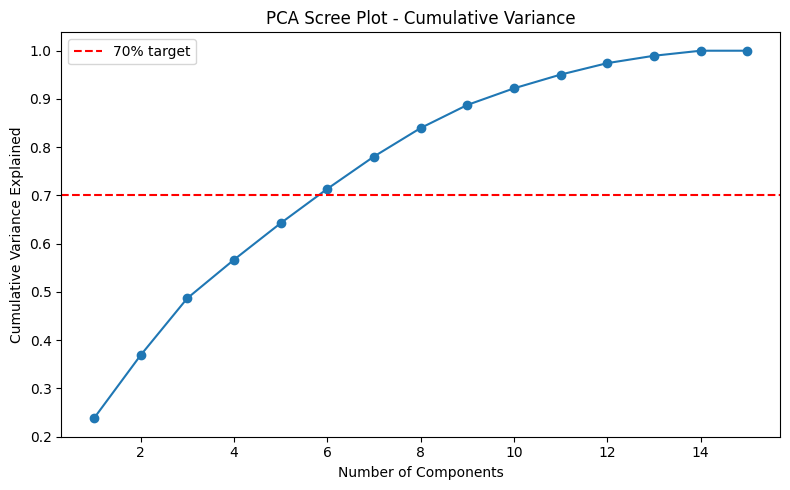

In [7]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker="o")
plt.axhline(y=0.70, color="red", linestyle="--", label="70% target")
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Variance Explained")
plt.title("PCA Scree Plot - Cumulative Variance")
plt.legend()
plt.tight_layout()
plt.show()

**Honest finding:** Using just 2-3 components only explains about 37-49% of
the total variance - well short of a 70% target. This makes sense because our
features cover several fairly *independent* aspects of a crime (where it happened,
when it happened, what type it was, whether there was an arrest) - these don't
naturally compress into just 2-3 dimensions the way, say, pixel data in an image
would. To reach 70%+ variance, we need 6 components.

We'll use **6 components** to honestly hit the 70% variance target, but for
visualization purposes (since humans can only easily view 2D plots), we'll use
just the first 2 components (PC1 and PC2).

In [8]:
pca = PCA(n_components=6, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("Variance explained by each component:", pca.explained_variance_ratio_.round(3))
print("Total variance explained (6 components):", round(sum(pca.explained_variance_ratio_), 3))
print("Variance explained by just first 3 components:", round(sum(pca.explained_variance_ratio_[:3]), 3))

Variance explained by each component: [0.238 0.131 0.118 0.08  0.076 0.071]
Total variance explained (6 components): 0.714
Variance explained by just first 3 components: 0.487


## Step 4: Which Features Drive Each Principal Component?

In [9]:
pc1_loadings = pd.Series(pca.components_[0], index=feature_columns).abs().sort_values(ascending=False)
print("Top 5 features driving PC1:")
print(pc1_loadings.head(5))

Top 5 features driving PC1:
latitude          0.501994
ward              0.470648
district          0.450299
community_area    0.414278
longitude         0.356320
dtype: float64


In [10]:
pc2_loadings = pd.Series(pca.components_[1], index=feature_columns).abs().sort_values(ascending=False)
print("Top 5 features driving PC2:")
print(pc2_loadings.head(5))

Top 5 features driving PC2:
is_weekend              0.616267
day_of_week_num         0.612013
crime_severity_score    0.289495
primary_type_encoded    0.278484
domestic                0.242341
dtype: float64


**Interpretation:** PC1 is mostly driven by geographic features (latitude,
ward, district, community_area, longitude) - this matches the project brief's
expectation that "location" would be one of the most important drivers of crime
patterns.

## Step 5: 2D Visualization Using PC1 and PC2

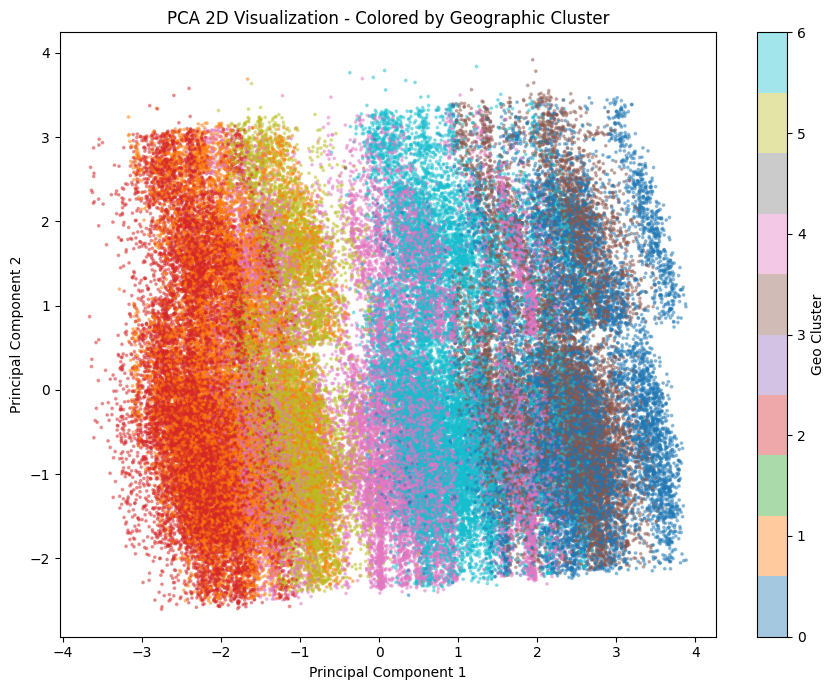

In [11]:
df["pca_1"] = X_pca[:, 0]
df["pca_2"] = X_pca[:, 1]
for i in range(2, 6):
    df[f"pca_{i+1}"] = X_pca[:, i]

plt.figure(figsize=(9, 7))
scatter = plt.scatter(df["pca_1"], df["pca_2"], c=df["geo_cluster_kmeans"], cmap="tab10", s=3, alpha=0.4)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization - Colored by Geographic Cluster")
plt.colorbar(scatter, label="Geo Cluster")
plt.tight_layout()
plt.show()

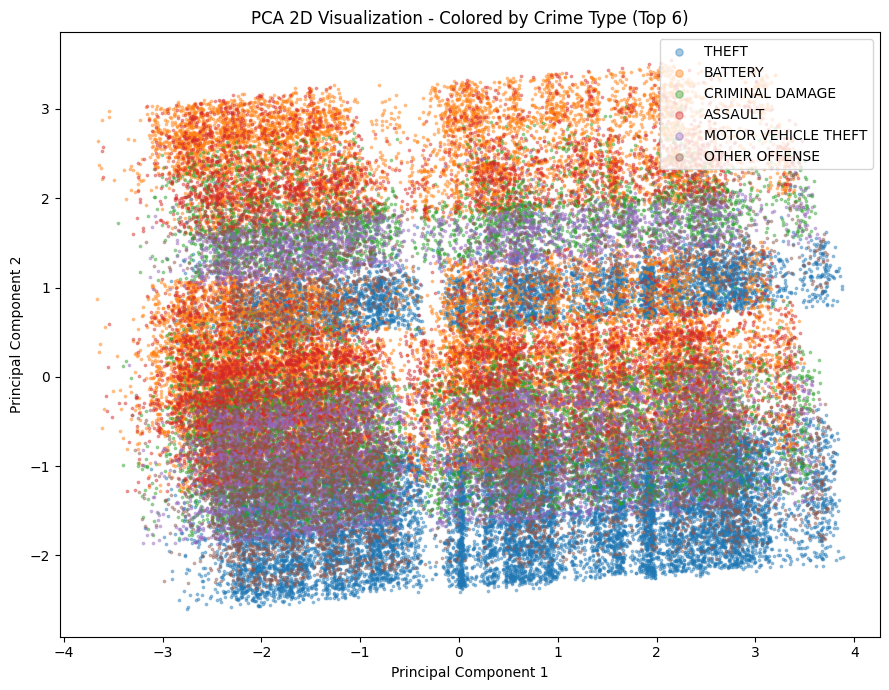

In [12]:
plt.figure(figsize=(9, 7))
top_types = df["primary_type"].value_counts().head(6).index
for crime_type in top_types:
    subset = df[df["primary_type"] == crime_type]
    plt.scatter(subset["pca_1"], subset["pca_2"], label=crime_type, s=3, alpha=0.4)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA 2D Visualization - Colored by Crime Type (Top 6)")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

## Step 6: t-SNE Visualization

**Why we only use a sample for t-SNE:** t-SNE is much slower than PCA because it
calculates relationships between every pair of points, similar to Hierarchical
Clustering. Running it on all 100,000 rows would take a very long time, so we use
a random sample of 5,000 points - this is a well-known, practical limitation of
t-SNE that most people work around this same way.

In [13]:
sample_idx = np.random.RandomState(42).choice(len(X_scaled), size=5000, replace=False)
X_sample = X_scaled[sample_idx]

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

tsne_df = df.iloc[sample_idx].copy()
tsne_df["tsne_1"] = X_tsne[:, 0]
tsne_df["tsne_2"] = X_tsne[:, 1]

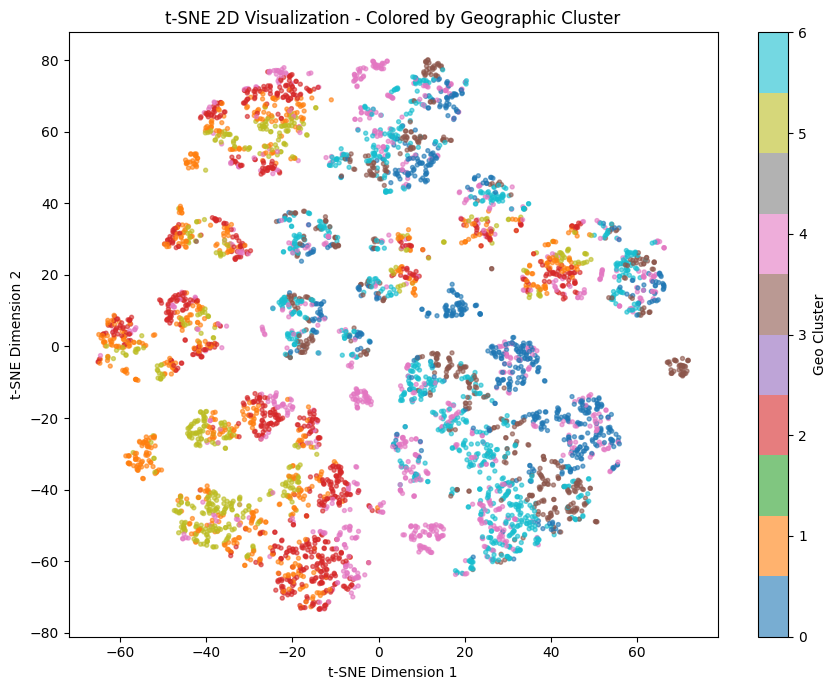

In [14]:
plt.figure(figsize=(9, 7))
scatter = plt.scatter(tsne_df["tsne_1"], tsne_df["tsne_2"], c=tsne_df["geo_cluster_kmeans"], cmap="tab10", s=8, alpha=0.6)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE 2D Visualization - Colored by Geographic Cluster")
plt.colorbar(scatter, label="Geo Cluster")
plt.tight_layout()
plt.show()

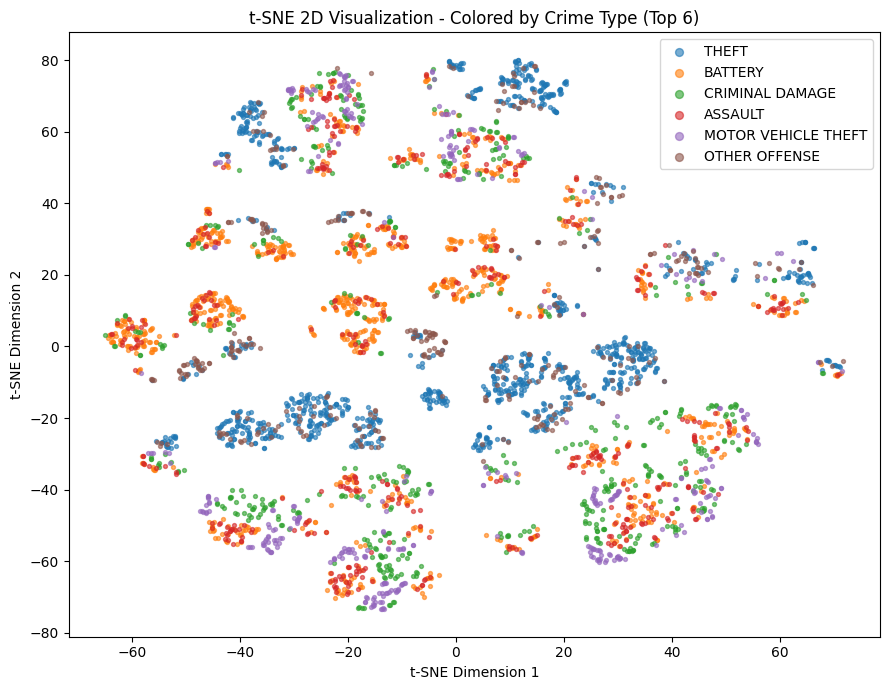

In [15]:
plt.figure(figsize=(9, 7))
top_types = tsne_df["primary_type"].value_counts().head(6).index
for crime_type in top_types:
    subset = tsne_df[tsne_df["primary_type"] == crime_type]
    plt.scatter(subset["tsne_1"], subset["tsne_2"], label=crime_type, s=8, alpha=0.6)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("t-SNE 2D Visualization - Colored by Crime Type (Top 6)")
plt.legend(markerscale=2)
plt.tight_layout()
plt.show()

**Comparing PCA and t-SNE:** PCA groups points more by geography (since
location has the most variance), while t-SNE tends to reveal tighter local
groupings - sometimes by crime type, sometimes by other combined factors. Neither
plot shows perfectly clean separation, which lines up with our clustering results -
crime data is messy and doesn't separate into perfectly distinct groups, which
is a realistic, honest finding rather than a flaw in our approach.

## Step 7: Save Results

In [16]:
df.to_csv("../outputs/data_with_pca.csv", index=False)
tsne_df.to_csv("../outputs/tsne_sample.csv", index=False)

joblib.dump(pca, "../models/pca_model.pkl")
joblib.dump(scaler_pca, "../models/scaler_pca.pkl")
joblib.dump(le_primary_type, "../models/label_encoder_primary_type.pkl")
joblib.dump(le_location_desc, "../models/label_encoder_location_desc.pkl")

print("Saved data_with_pca.csv, tsne_sample.csv, and models.")

Saved data_with_pca.csv, tsne_sample.csv, and models.
